In [1]:
import warnings

import pandas as pd

warnings.filterwarnings("ignore")
warnings.simplefilter("ignore")

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pertpy as pt
import scanpy as sc
import seaborn as sns

In [2]:
# Load in data

# import preprocessed dataset

dir = "PBMC_datasets/1/PBMC1_clustering.h5ad"

adata = sc.read(dir)

In [3]:
adata

AnnData object with n_obs × n_vars = 54057 × 19936
    obs: 'gsm_id', 'diagnosis', 'age', 'gender', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'leiden_res2', 'manual_celltype_annotation_0_25', 'celltypist_cell_label_coarse', 'celltypist_conf_score_coarse', 'celltypist_cell_label_fine', 'celltypist_conf_score_fine'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'celltypist_cell_label_coarse_colors', 'celltypist_cell_label_fine_colors', 'dendrogram_leiden_res0_25', 'gend

In [4]:
# Compositional analysis (using scCODA)

#instantiate scCODA model and create MuData object 

sccoda_model = pt.tl.Sccoda()
sccoda_data = sccoda_model.load(
    adata,
    type="cell_level",
    generate_sample_level=True,
    cell_type_identifier="celltypist_cell_label_coarse",
    sample_identifier="sample",
    covariate_obs=["diagnosis"],
)
sccoda_data

MuData object with n_obs × n_vars = 54063 × 19944
  var:	'n_cells'
  2 modalities
    rna:	54057 x 19936
      obs:	'gsm_id', 'diagnosis', 'age', 'gender', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'leiden_res2', 'manual_celltype_annotation_0_25', 'celltypist_cell_label_coarse', 'celltypist_conf_score_coarse', 'celltypist_cell_label_fine', 'celltypist_conf_score_fine', 'scCODA_sample_id'
      var:	'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
      uns:	'celltypist_cell_label_coarse_colors', 'celltypist_cell_label_fine_colors', 'dendrogram_leiden_res0_25', 'gender_colors', 'hvg', 'leiden_res0_25', 'leiden_res0_25_colors', 'leiden_res0_5', 'leiden_res0_5_colors', 'leiden_res1', 'leiden_res1_colors', 'leiden_res2', 'leiden_res2_colors', 'manual_celltype_annotation_0_25_colors', 'neighbors', 'pca', 'sample_colors', 'scrublet', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	'counts', 'log1p_norm'
      obsp:	'connectivities', 'distances'
    coda:	6 x 8
      obs:	'diagnosis', 'sample'
      var:	'n_cells'

TypeError: seaborn.categorical.swarmplot() got multiple values for keyword argument 'palette'

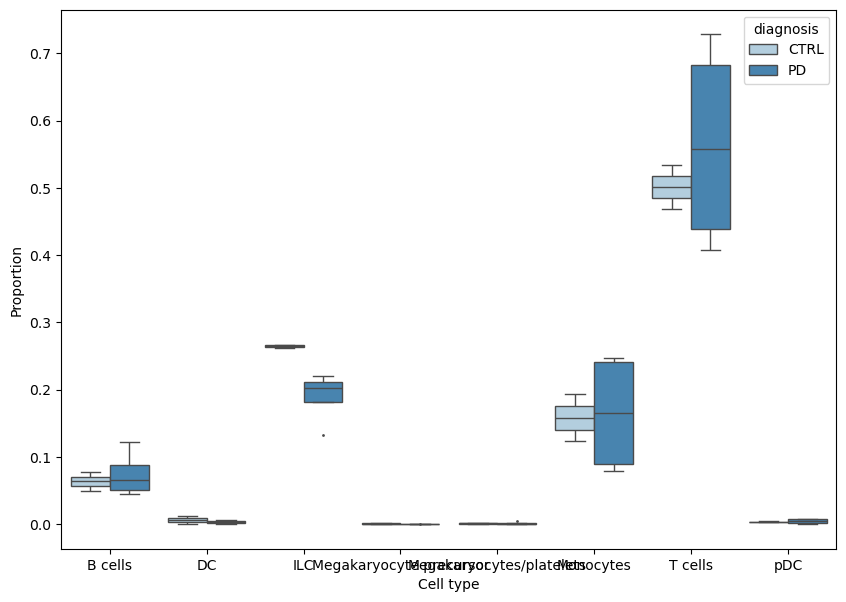

In [5]:
# get overview of cell type distributions w boxplots
sccoda_model.plot_boxplots(
    sccoda_data,
    modality_key="coda",
    feature_name="diagnosis",
    figsize=(10, 7),
    add_dots=True,
    args_swarmplot={"palette": ["red"]},
)
plt.show()

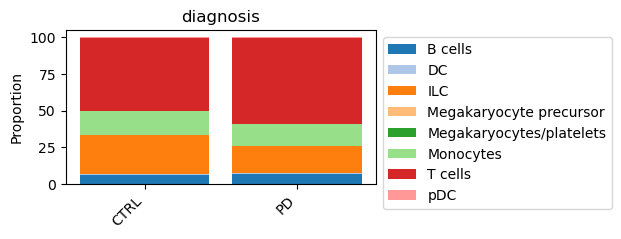

In [6]:
# alternative visualisation with stacked barplot

sccoda_model.plot_stacked_barplot(
    sccoda_data, modality_key="coda", feature_name="diagnosis", figsize=(4, 2)
)
plt.show()

In [7]:
# checking the baseline category for diagnosis (for interpretation of results later on)
sccoda_data["coda"].obs["diagnosis"].cat.categories

Index(['CTRL', 'PD'], dtype='object')

In [7]:
# run scCODA model
sccoda_data = sccoda_model.prepare(
    sccoda_data,
    modality_key="coda",
    formula="diagnosis",
    reference_cell_type="automatic", # letting scCODA choose the reference cell type automatically
)
sccoda_model.run_nuts(sccoda_data, modality_key="coda", rng_key=1234)

sample: 100%|██████████| 11000/11000 [00:40<00:00, 272.37it/s, 127 steps of size 3.30e-02. acc. prob=0.87]


In [8]:
sccoda_data["coda"].varm["effect_df_diagnosis[T.PD]"]

,Final Parameter,HDI 3%,HDI 97%,SD,Inclusion probability,Expected Sample,log2-fold change
celltypist_cell_label_coarse,,,,,,,
B cells,0.0,-0.421,0.555,0.168,0.4641,639.396549,0.0
DC,0.0,-0.610,0.677,0.233,0.5026,70.352959,0.0
ILC,0.0,-0.696,0.134,0.207,0.5718,2072.528916,0.0
Megakaryocyte precursor,0.0,-0.786,0.635,0.257,0.5171,28.977650,0.0
Megakaryocytes/platelets,0.0,0.000,0.000,0.000,0.0000,42.246641,0.0
Monocytes,0.0,-0.492,0.314,0.142,0.4522,1374.059586,0.0
T cells,0.0,-0.272,0.427,0.126,0.4400,4705.676566,0.0
pDC,0.0,-0.702,0.512,0.218,0.4984,76.594467,0.0


In [ ]:
# from the above table, it seems none of the cell types are significantly differentially abundant between the two conditions (since all 95% credible intervals include 0). Likely underpowered to observe any differences (6 samples)

6

In [22]:
# trying with a less stringent FDR threshold to see if any cell types are identified as differentially abundant
sccoda_model.set_fdr(sccoda_data, 0.2)
sccoda_model.credible_effects(sccoda_data, modality_key="coda")


Covariate        Cell Type               
diagnosis[T.PD]  B cells                     False
                 DC                          False
                 ILC                         False
                 Megakaryocyte precursor     False
                 Megakaryocytes/platelets    False
                 Monocytes                   False
                 T cells                     False
                 pDC                         False
Name: Final Parameter, dtype: bool

In [23]:
# return to default FDR threshold of 0.05 for downstream analyses

sccoda_model.set_fdr(sccoda_data, 0.2)
sccoda_model.credible_effects(sccoda_data, modality_key="coda")

Covariate        Cell Type               
diagnosis[T.PD]  B cells                     False
                 DC                          False
                 ILC                         False
                 Megakaryocyte precursor     False
                 Megakaryocytes/platelets    False
                 Monocytes                   False
                 T cells                     False
                 pDC                         False
Name: Final Parameter, dtype: bool

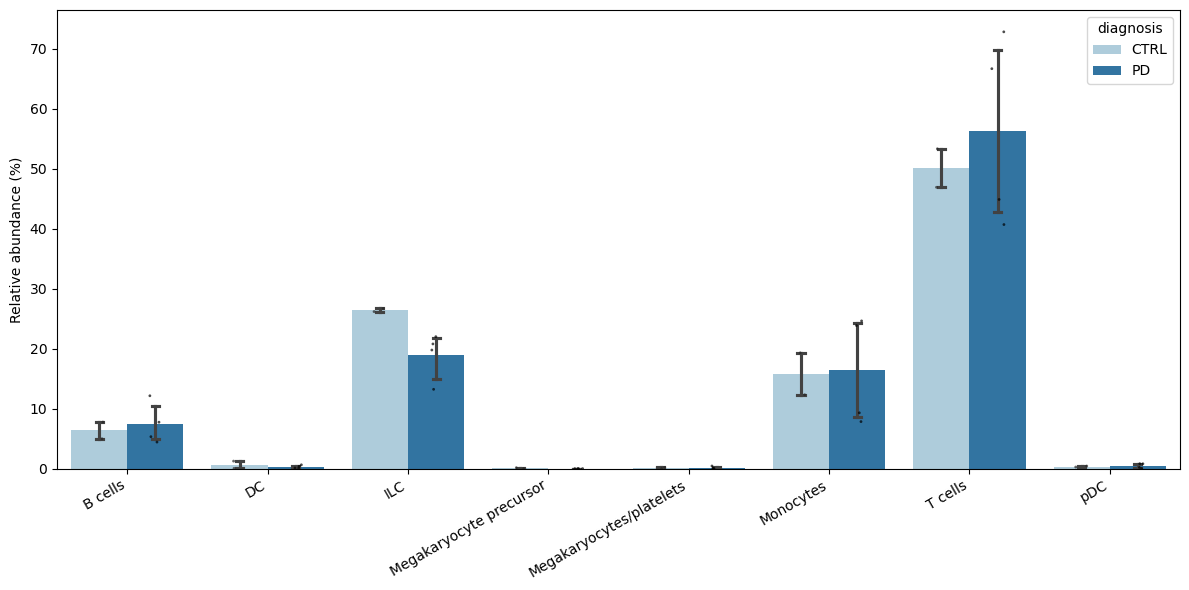

In [ ]:
# plot relative abundances of cell types across the two conditions

coda = sccoda_data["coda"]

# counts -> dataframe
df = pd.DataFrame(
    coda.X,
    index=coda.obs_names,
    columns=coda.var_names
)

# relative abundances
df = df.div(df.sum(axis=1), axis=0) * 100

# add group label
df["diagnosis"] = coda.obs["diagnosis"].values

# long format
plot_df = df.reset_index(names="sample").melt(
    id_vars=["sample", "diagnosis"],
    var_name="cell_type",
    value_name="rel_abundance"
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=plot_df,
    x="cell_type",
    y="rel_abundance",
    hue="diagnosis",
    errorbar=("ci", 95),
    capsize = 0.1,
    palette= "Paired"
)
sns.stripplot(
    data=plot_df,
    x="cell_type",
    y="rel_abundance",
    hue="diagnosis",
    dodge=True,
    color="black",
    alpha=0.7,
    size=2,
    legend = False
)

plt.xticks(rotation=30, ha="right")
plt.ylabel("Relative abundance (%)")
plt.xlabel("")
plt.tight_layout()
plt.show()

# should i add a ns annotation to indicate non-significant differences?

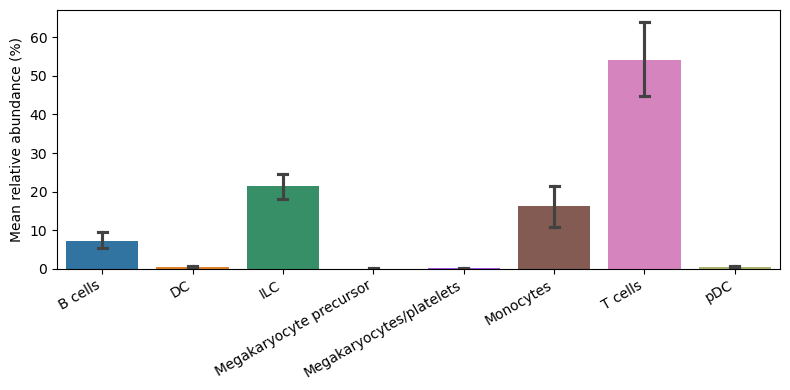

In [71]:
# derive colors of annotations from the original adata object
labels = adata.obs["celltypist_cell_label_coarse"].astype("category").cat.categories
colors = adata.uns["celltypist_cell_label_coarse_colors"]
cell_type_colors_dict = dict(zip(labels, colors))


# convert to long format for plotting
plot_df = df.reset_index(names="sample").melt(
    id_vars=["sample", "diagnosis"], # so it doesnt think diagnosis is another celltype
    var_name="cell_type",
    value_name="rel_abundance"
)

# plot overall relative abundance of each cell type across all samples with 95% CI, and colors corresponding to the cell types in UMAP
plt.figure(figsize=(8, 4))
sns.barplot(
    data=plot_df,
    x="cell_type",
    y="rel_abundance",
    hue="cell_type",
    palette=cell_type_colors_dict,
    dodge=False,
    legend=False,
    errorbar=("ci", 95),
    capsize=0.1,
)

plt.xticks(rotation=30, ha="right")
plt.ylabel("Mean relative abundance (%)")
plt.xlabel("")
plt.tight_layout()
plt.show()

In [69]:
df

celltypist_cell_label_coarse,B cells,DC,ILC,Megakaryocyte precursor,Megakaryocytes/platelets,Monocytes,T cells,pDC,diagnosis
scCODA_sample_id,,,,,,,,,
1,4.981491,1.258593,26.716023,0.158646,0.211528,19.312533,46.927552,0.433633,CTRL
2,7.774205,0.042872,26.195070,0.007145,0.042872,12.318685,53.347624,0.271526,CTRL
3,4.433535,0.098187,13.232628,0.007553,0.030211,9.312689,72.854985,0.030211,PD
4,5.334155,0.110872,19.784416,0.006160,0.012319,7.847244,66.707730,0.197105,PD
5,12.155547,0.407018,22.011991,0.005500,0.011000,23.871074,40.712832,0.825037,PD
6,7.753021,0.642593,20.800447,0.006985,0.447021,24.642034,44.897674,0.810226,PD
